In [7]:
import pandas as pd
from scipy.stats import randint
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV 
from sklearn import metrics 
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix

#Dataset: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction/data

In [1]:
#1 feladat: Töltsed be a csv-t és printeld ki az első 10 sorát!

In [8]:
df = pd.read_json('heart.json')
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [ ]:
#2.feladat: Cseréld ki a Sex oszlop értékeit 0-ra és 1-re!

In [9]:
df['Sex'] = df['Sex'].replace({'M': 0, 'F': 1})

In [ ]:
#3. feladat: Nézd meg hogy az egyes oszlopokban milyen típusú adatok vannak!
# Válaszd ki azokat az oszlopokat, amik számmal jellemezhetőek, készíts egy új dataframet ezek alapján és plotold ezek korrelációját!

In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(1), str(4)
memory usage: 93.2+ KB


In [11]:
numeric_columns = df.select_dtypes(include=['int', 'float'])
new_df = df[numeric_columns.columns]


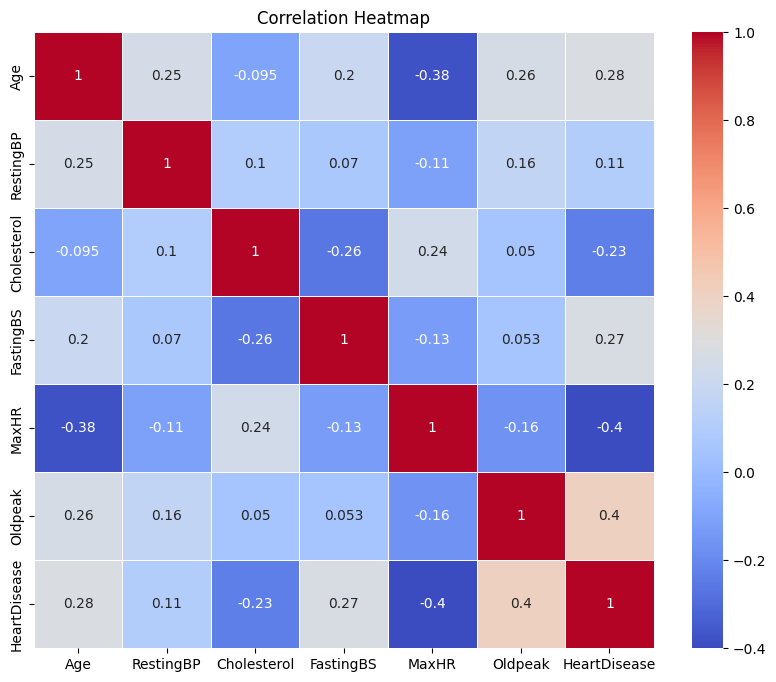

In [12]:
corr_matrix = new_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


In [ ]:
#4. feladat: Készíts egy hisztogrammot a 'age' oszlop alapján!

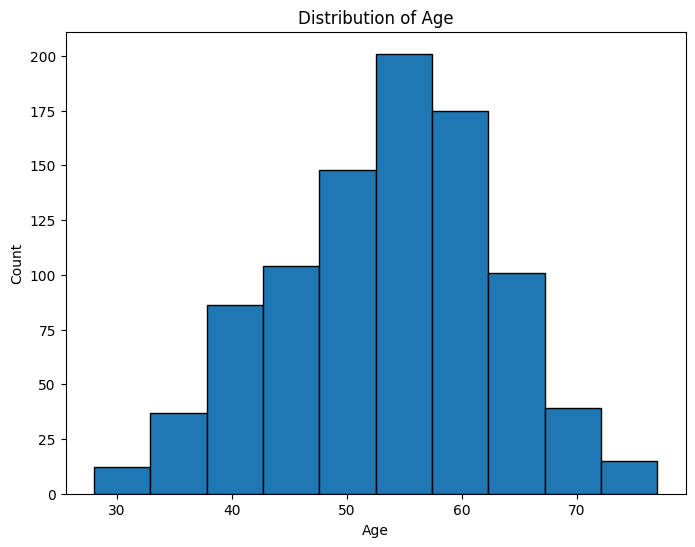

In [13]:
plt.figure(figsize=(8, 6))
plt.hist(df['Age'], bins=10, edgecolor='k')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Distribution of Age')
plt.show()

In [ ]:
#5.feladat: Készíts egy oszlop diagrammot amely bemutatja a nemek eloszlását!

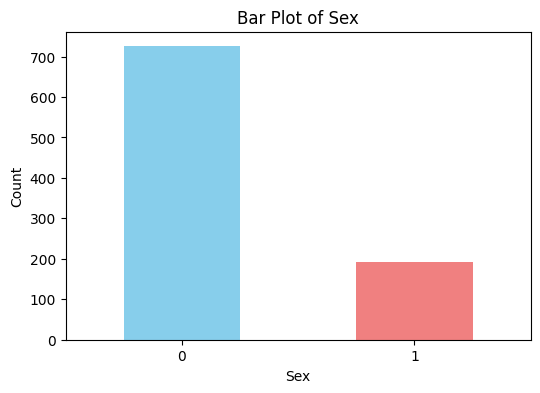

In [14]:
plt.figure(figsize=(6, 4))
df['Sex'].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Bar Plot of Sex')
plt.xticks(rotation=0)
plt.show()


In [ ]:
#6. feladat: Készíts egy 'box' plotot amely megmutaja hogy a ChestPainType-okhoz milyen MaxHR eloszlás tartozik!

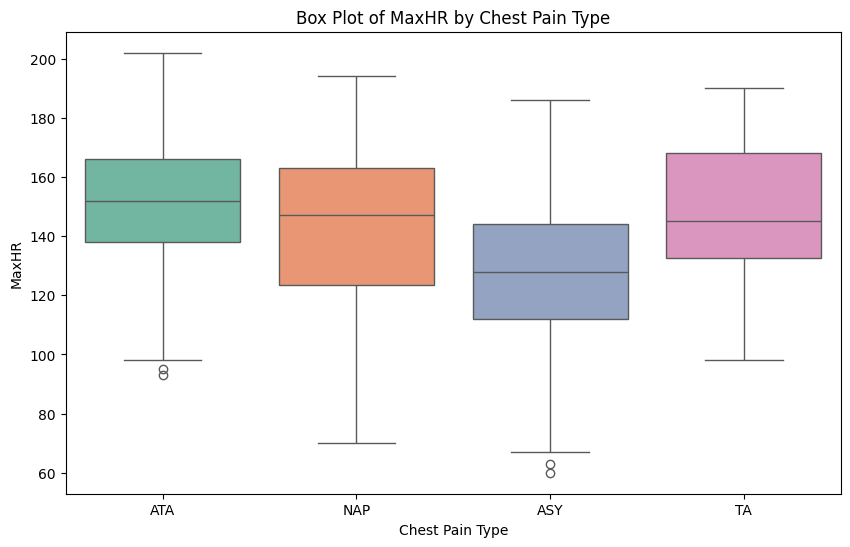

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='ChestPainType', y='MaxHR', hue='ChestPainType', data=df, palette='Set2', legend=False)
plt.xlabel('Chest Pain Type')
plt.ylabel('MaxHR')
plt.title('Box Plot of MaxHR by Chest Pain Type')
plt.show()

In [ ]:
#7. feladat: Néhány mondatban foglald össze, hogy milyen következtetéseket vonhatunk le az adatokból az eddigi vizualizációk alapján!
#(ha szükséges akkor készíts újabb vizualizációkat, amik szerinted hasznosak lehetnek) 

In [ ]:
#8. feldata: Készíts egy X és egy y változót, amelyek a tanító adatokat és a HeartDisease oszlopot tartalmazzák!
#Figyelj rá, hogy csak azokat az oszlopokat válaszd ki, amelyek számmal jellemezhetőek!

In [16]:
X = new_df.drop('HeartDisease', axis=1)
y = new_df['HeartDisease']

In [ ]:
#9. feladat: Spliteld az adatokat train és test adatokra! (70-30 arányban)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
#10. feladat: Taníts fel egy DecisionTreeClassifier-t a train adatokon!

In [18]:
clf = DecisionTreeClassifier()
clf = clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [ ]:
#11. feladat: Printeld ki milyen pontosságot értél el a modell segítségével!

In [19]:
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.6811594202898551


In [20]:
#12. feladat: Taníts fel egy RandomForestClassifier-t a train adatokon, Randomized Search segítségével!
#paraméterek: 
param_dist = {'n_estimators': np.random.randint(50,500), 'max_depth': np.random.randint(1,20)}

#https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html

In [21]:
rf = RandomForestClassifier()

# Define the parameter distributions
param_dist = {'n_estimators': randint(50, 500), 'max_depth': randint(1, 20)}

# Use random search to find the best hyperparameters
rand_search = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=5, cv=5)

# Fit the random search object to the data
rand_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': <scipy.stats....00213A5F49D10>, 'n_estimators': <scipy.stats....00213A5F41FD0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if

In [ ]:
#13. feladat: Printeld ki a legjobb paramétereket! (n_estimators, max_depth)

In [22]:
best_rf = rand_search.best_estimator_

# Print the best hyperparameters
print('Best hyperparameters:',  rand_search.best_params_)

Best hyperparameters: {'max_depth': 4, 'n_estimators': 283}


In [ ]:
#14.feladat: Prediktálj a teszt adatokra és printeld ki az accuracy-t!

In [23]:
y_pred = best_rf.predict(X_test)
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.7862318840579711


In [ ]:
#15. feladat: Készíts egy confusion matrixot a predikciók alapján!

<Axes: >

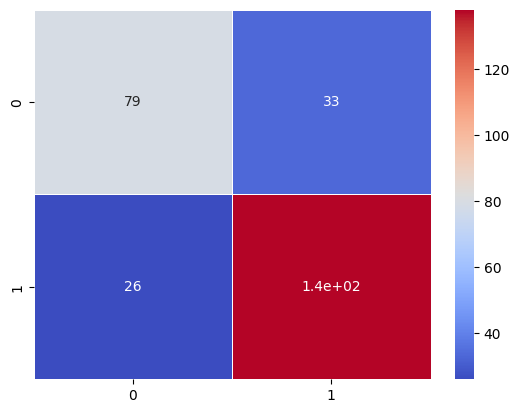

In [24]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='coolwarm', linewidths=0.5)

In [ ]:
#16. feladat: Vizualizáld a Random Forest modell első döntési fáját!

<function matplotlib.pyplot.show(close=None, block=None)>

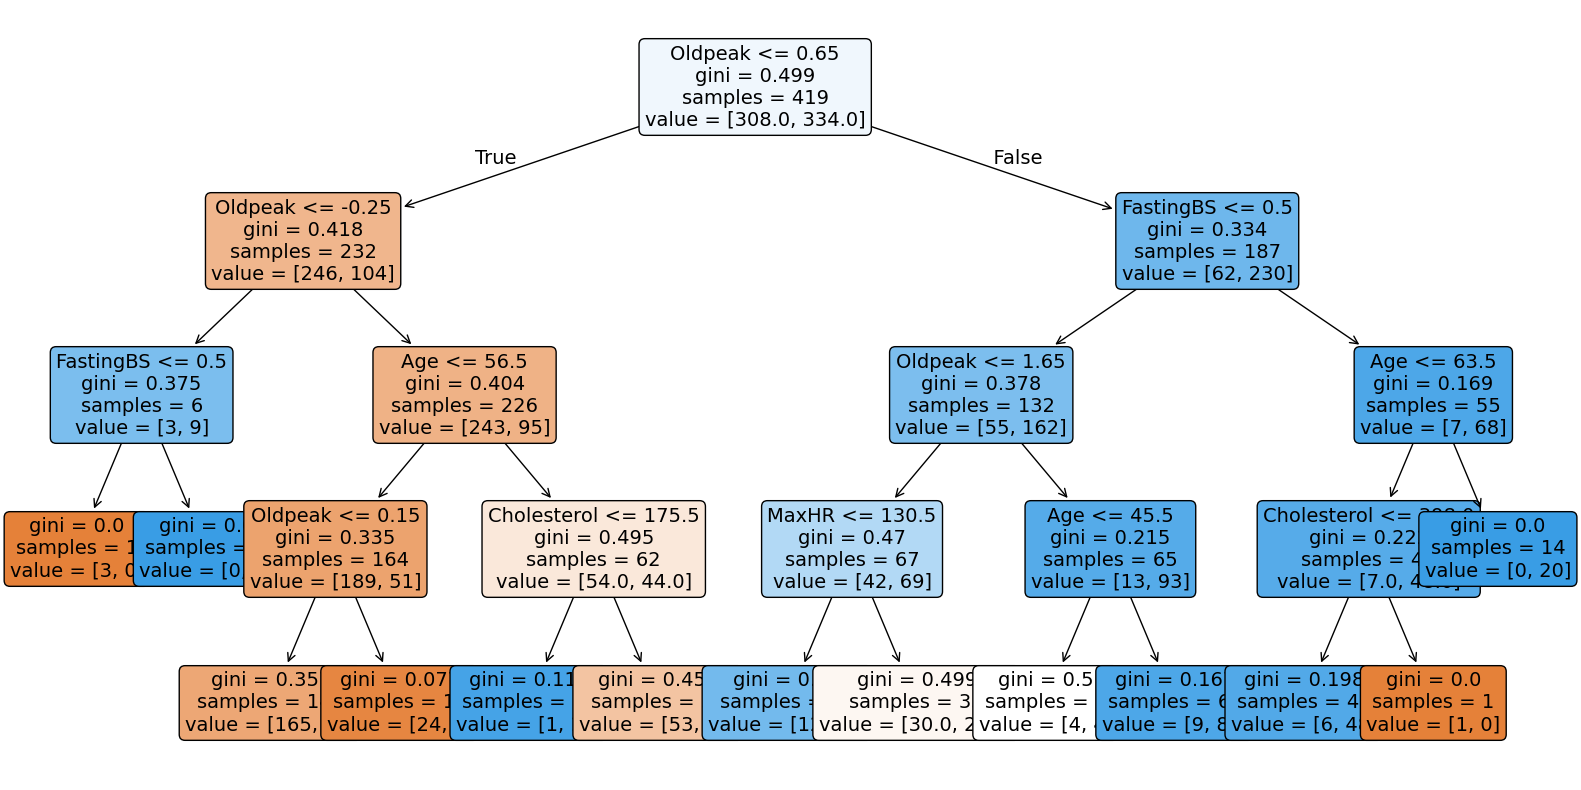

In [25]:
plt.figure(figsize=(20, 10))
plot_tree(best_rf.estimators_[0], feature_names=X.columns, filled=True, rounded=True, fontsize=14)
plt.show